In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from elfdannagalac.dmspectrum import dmspectra

In [2]:
dme_spec = dmspectra.dmspectrum(10000.,100,9000,channel='tau')
dmengs   = dme_spec.engs
dmengsdn = dme_spec.spectrum()


In [3]:
eng_events = []
weigths    = []

for id in range(10):
    fpath = f'/lustre/hawcz01/scratch/userspace/sergio/EDCTestsScienceCase2/Sim{id:04d}'
    fname = os.path.join(fpath,'SphPhotonObserver.txt')
    df = pd.read_csv(fname, delimiter='\t', names=["E","X","Y","Z","W"], comment='#')
    for jd in range(df['E'].to_numpy().size):
        eng_events.append(df['E'].to_numpy()[jd])
        weigths.append(df['W'].to_numpy()[jd])

In [4]:
len(eng_events)

19564799

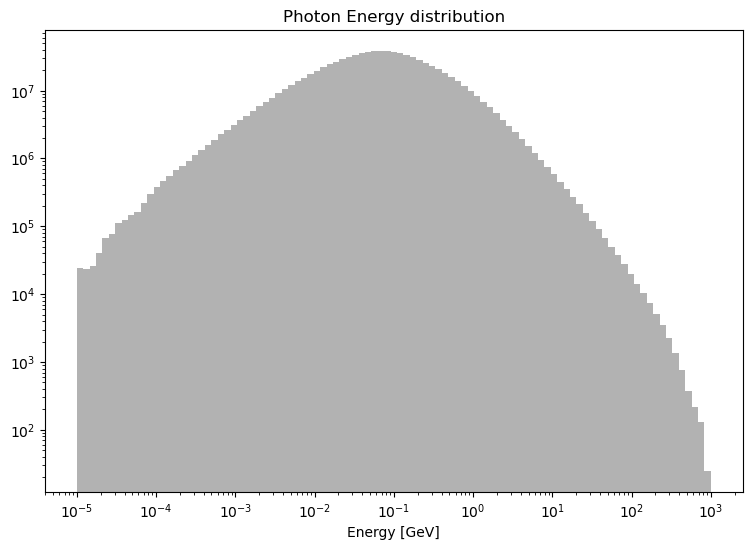

In [5]:
_,ax = plt.subplots(figsize=(9,6))

nbins = np.logspace(-5,3,100)
vals,vbins = np.histogram(eng_events,bins=nbins,weights=weigths)
ax.stairs(vals,vbins,fill=True,color='gray',alpha=0.6)
ax.set_title('Photon Energy distribution')
ax.set_xlabel('Energy [GeV]')
ax.set_xscale('log')
ax.set_yscale('log')

# Checking for electrons

In [6]:
electron_engs = []

for id in range(10):
    fpath  = f'/lustre/hawcz01/scratch/userspace/sergio/EDCTestsScienceCase2/Sim{id:04d}'
    fname  = os.path.join(fpath,'ElectronsSphPhotonObserver.txt')
    names  = ["D","SN","E","SN0","E0","X0","Y0","Z0","SN1"]
    dtypes = [float,int,float,int,float,float,float,float,int]
    data   = np.loadtxt(fname,dtype={'names':names,'formats':dtypes})
    indices = np.unique(data['SN0'])
    for jd in range(data['E0'][indices].size):
        electron_engs.append(data['E0'][indices][jd])

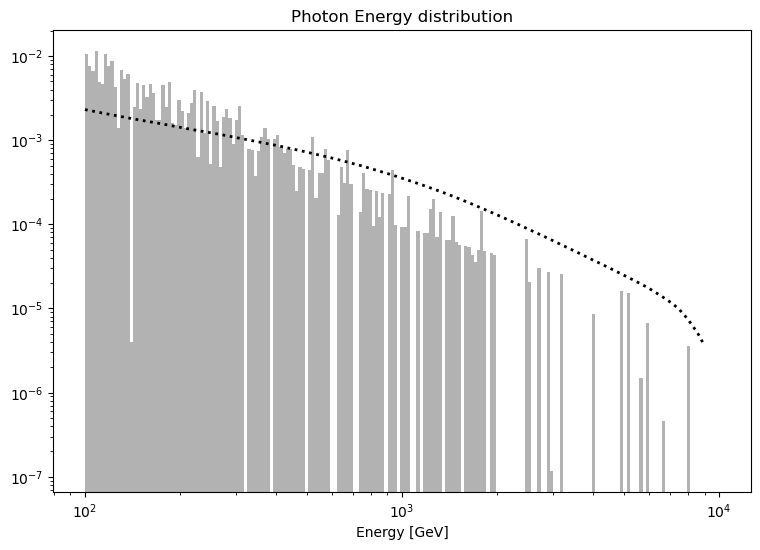

In [11]:
_,ax = plt.subplots(figsize=(9,6))

nbins = np.logspace(2,4,200)
evals,evbins = np.histogram(electron_engs,bins=nbins,density=True)
ax.stairs(evals,evbins,fill=True,color='gray',alpha=0.6)
ax.plot(dmengs,dmengsdn,lw=2,ls=':',color='black')
ax.set_title('Photon Energy distribution')
ax.set_xlabel('Energy [GeV]')
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(1,1e+4)

In [12]:
len(electron_engs)

999994

In [15]:
np.savetxt('Ephotonevents.txt',np.array([eng_events,weigths]).transpose(),fmt='%1.4e',delimiter='\t')

In [16]:
np.savetxt('Eelectronevents.txt',electron_engs,fmt='%1.4e')